<a href="https://colab.research.google.com/github/Pranoti15/My-DS-Projects/blob/my-branch/EDA_assignment4_housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()  # Opens a file selection dialog

Saving Housing.csv to Housing.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

Mounted at /content/drive


In [4]:
# Move uploaded file to Google Drive
!mv Housing.csv "/content/drive/My Drive/Data Science/Kaggle Datasets"

In [5]:
import pandas as pd

file_path = "/content/drive/My Drive/Data Science/Kaggle Datasets/Housing.csv"  # Change to your folder path
df = pd.read_csv(file_path)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
# Display summary statistics for numerical columns
summary_stats = df.describe()

# Check for missing values
missing_values = df.isnull().sum()

# Display both summary statistics and missing values count
summary_stats, missing_values

(              price          area    bedrooms   bathrooms     stories  \
 count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
 mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
 std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
 min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
 25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
 50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
 75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
 max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   
 
           parking  
 count  545.000000  
 mean     0.693578  
 std      0.861586  
 min      0.000000  
 25%      0.000000  
 50%      0.000000  
 75%      1.000000  
 max      3.000000  ,
 price               0
 area                0
 bedrooms            0
 bathrooms           0
 stories             0
 mainroad            0
 gue

**Step 1: Data Inspection**

**Summary Statistics:**

The dataset has 545 rows for all columns.

The price of houses ranges from 1.75 million to 13.3 million, with an average price of approximately 4.77 million.

Area ranges from 1,650 to 16,200 square feet, with a mean of around 5,150 square feet.

The number of bedrooms ranges from 1 to 6, with most houses having 2 to 3 bedrooms.

Other columns like bathrooms, stories, and parking also show expected ranges of values.

**Missing Values:**

There are no missing values in any of the columns.

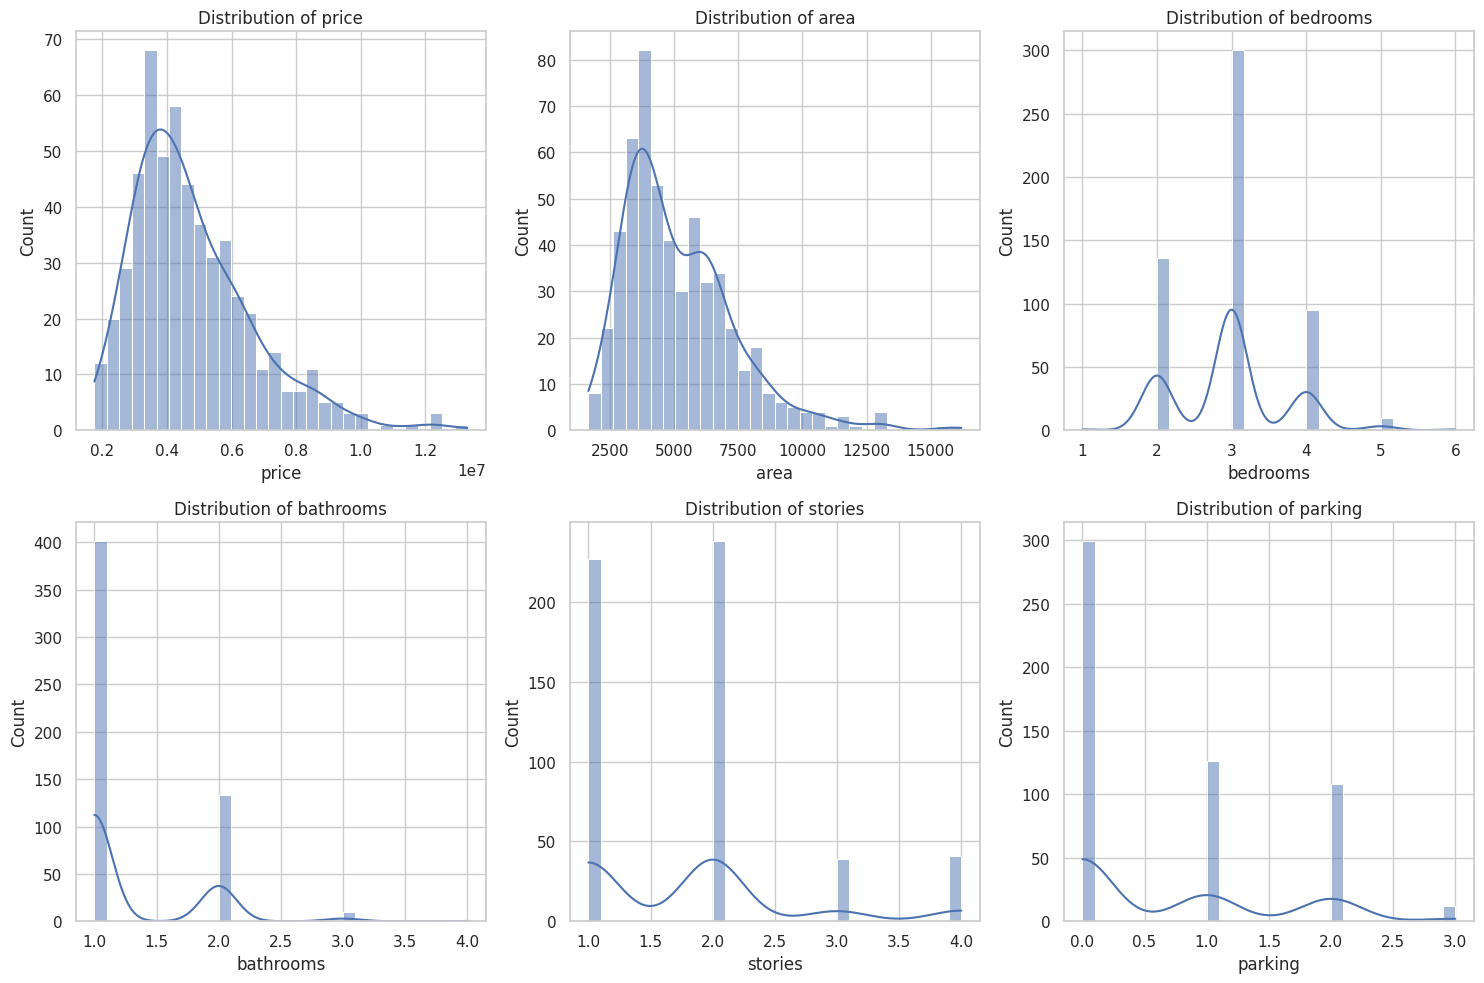

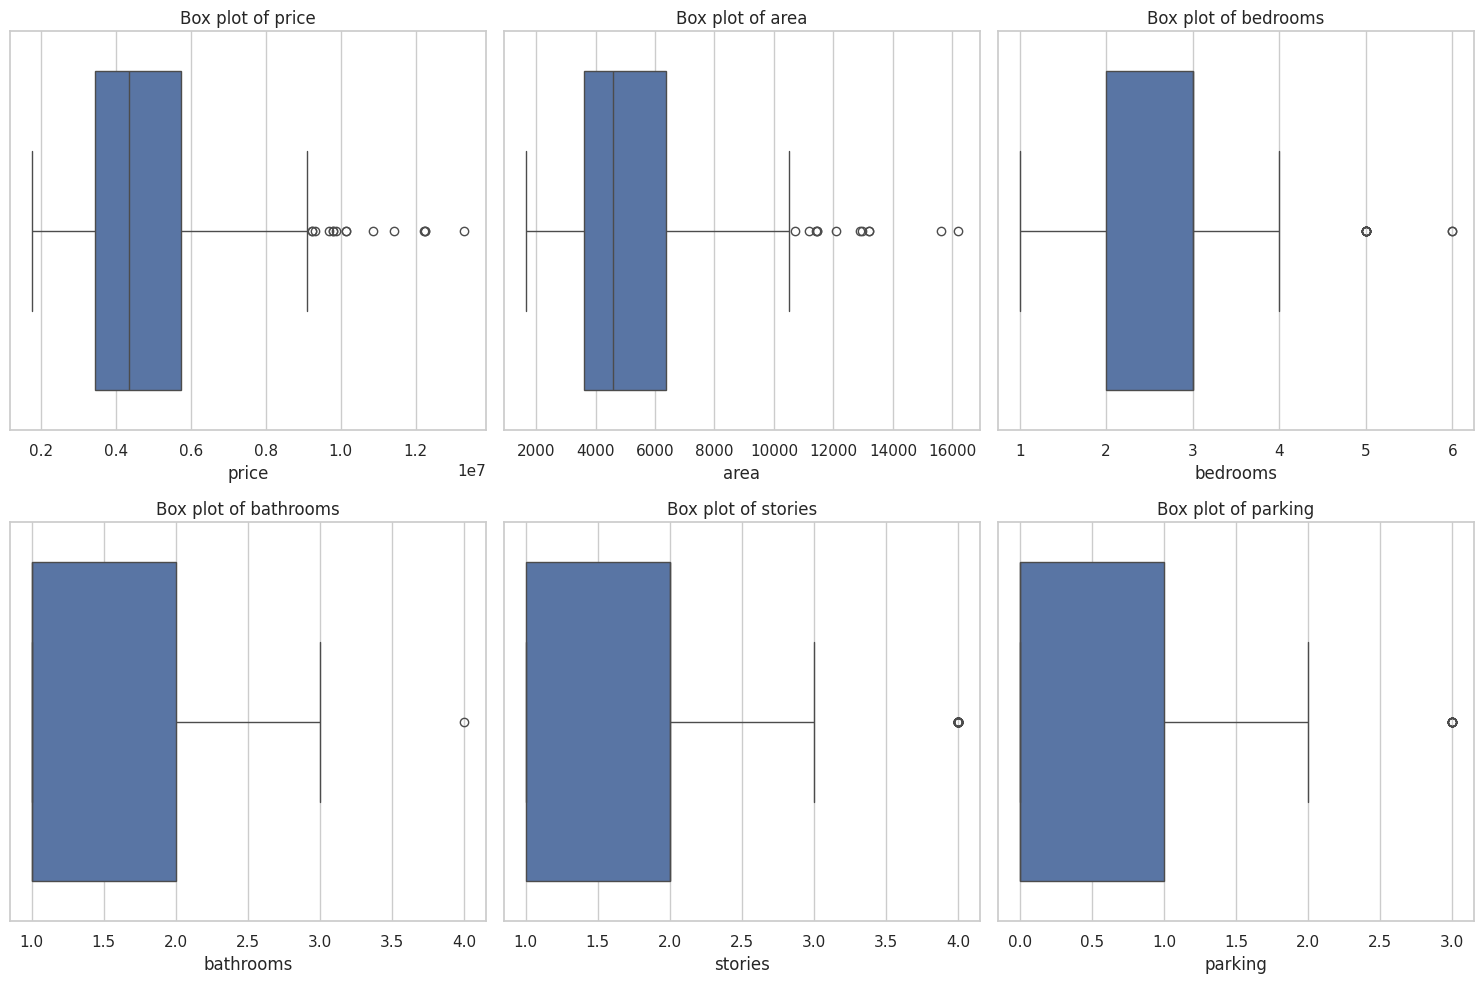

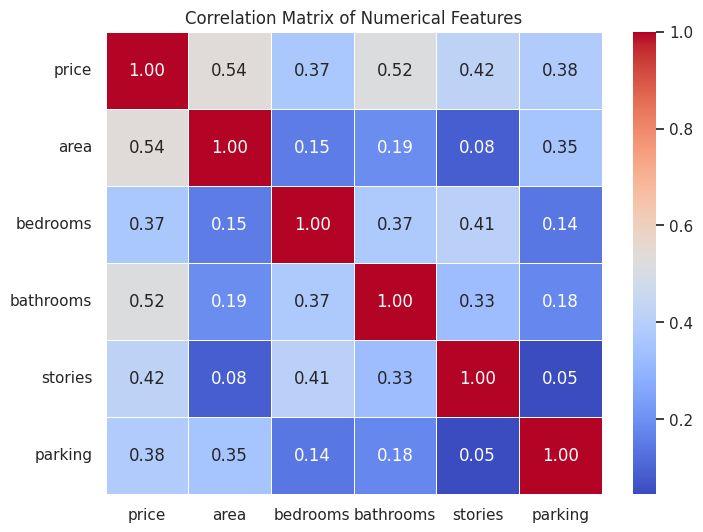

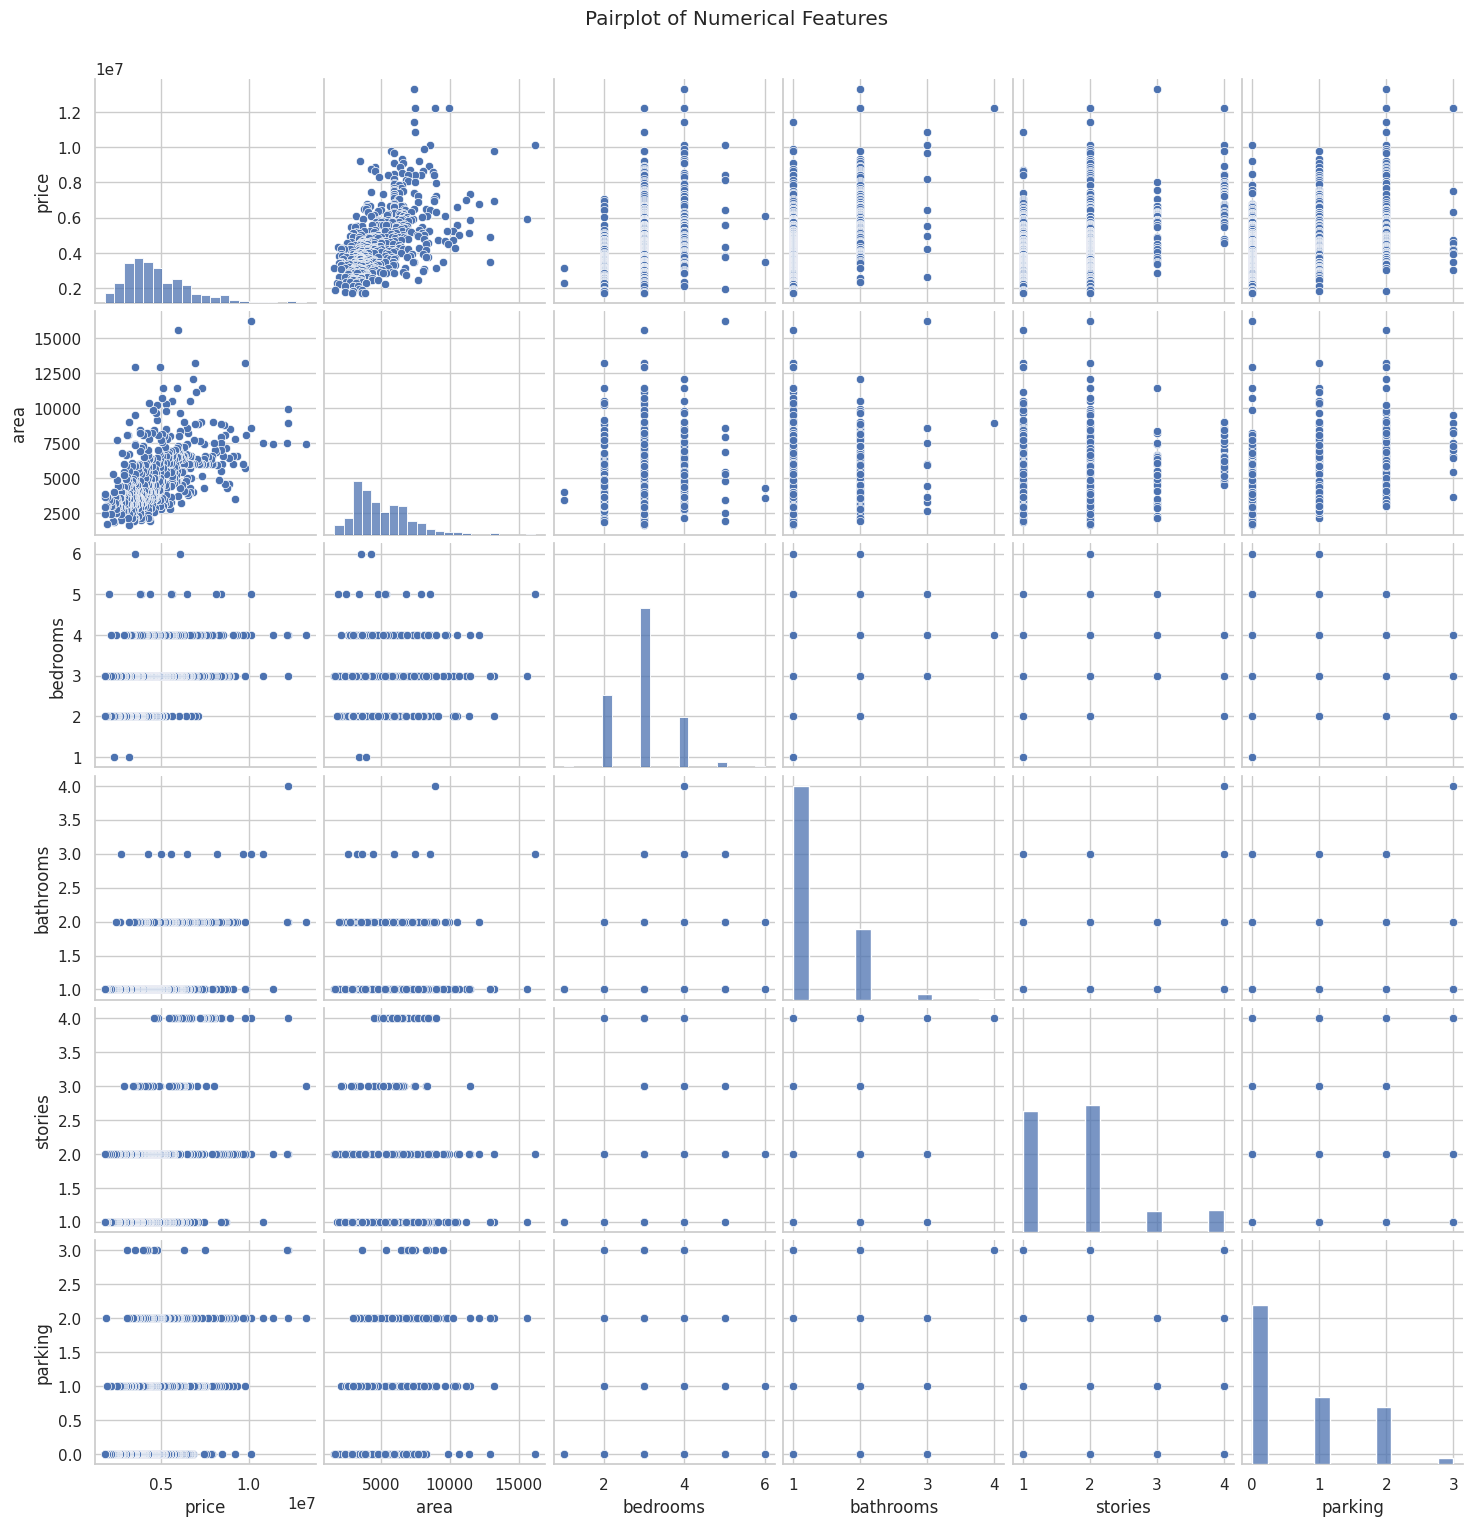

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot style
sns.set(style="whitegrid")

# Plot histograms for numerical features
numerical_columns = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

# Correlation matrix for numerical features
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Scatter plot matrix for numerical features
sns.pairplot(df[numerical_columns])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()


**Step 2: Exploratory Data Analysis (EDA) Insights**

**Histograms**: The histograms reveal the distributions of various numerical features:

The price distribution is skewed to the right, indicating that most house prices are on the lower end of the scale, with a few high-end properties.

The area and bedrooms also have right-skewed distributions.

**Box Plots**: These highlight the presence of outliers, especially in the price and area columns.

Prices seem to have some extreme values at the higher end.

**Correlation Matrix**:

There is a relatively strong positive correlation between area and price, suggesting that larger houses tend to be more expensive.

Bedrooms and bathrooms also have some positive correlation with each other and with area.

**Pairplot**: The scatter plot matrix gives a detailed view of relationships between multiple features. Area and price show a clear positive trend, while bedrooms, bathrooms, and stories do not show strong correlations with each other.

In [9]:
#We will proceed with encoding categorical variables and normalizing the data.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables using LabelEncoder
categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Normalize numerical features using StandardScaler
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display the first few rows after preprocessing
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4.566365,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,0
1,4.004484,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,0
2,4.004484,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,1
3,3.985755,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,0
4,3.554979,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,0


**Step 3: Preprocessing Insights**

**Categorical Encoding**: All categorical variables (e.g., mainroad, guestroom, basement, etc.) have been encoded into numeric values (0 or 1).

**Normalization**: The numerical columns have been normalized, so their values now range from approximately -3 to 3. This is done to ensure that features with different units or scales do not dominate machine learning models.

**Step 4: Summary of Insights**

**Key Observations:**

- Price is highly dependent on area, which is consistent with common knowledge that larger houses tend to have higher prices.

- Variables like number of bedrooms and bathrooms do not show strong correlations with the price, but they might still have subtle influences when considered in models.

**Influential Variables:**

- Area and price appear to be the most influential variables. The relationship between these variables should be explored further in any predictive modeling.

#The END